setup

In [6]:
import pandas as pd
import numpy as np
import os

import warnings
warnings.filterwarnings('ignore')

from six.moves import urllib

import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

data cleaning

In [7]:
import kagglehub

path = kagglehub.dataset_download("shivam2503/diamonds")

print("Path to dataset files:", path)
path = kagglehub.dataset_download("shivam2503/diamonds")

print(path)
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "diamonds.csv"))

Using Colab cache for faster access to the 'diamonds' dataset.
Path to dataset files: /kaggle/input/diamonds
Using Colab cache for faster access to the 'diamonds' dataset.
/kaggle/input/diamonds
['diamonds.csv']


In [8]:
df.head(6)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48


In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [11]:
df[df.isna().all(axis=1)]

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z


In [12]:
df.dropna(how='all',inplace=True)

In [13]:
df.reset_index(drop=True, inplace=True)

In [14]:
df.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [15]:

df.drop('Unnamed: 0', axis=1, inplace=True, errors='ignore')



In [16]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [17]:
df.to_csv("new_data.csv", index=False)

eda

In [18]:
#  Separate columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

Numerical Columns: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
Categorical Columns: ['cut', 'color', 'clarity']


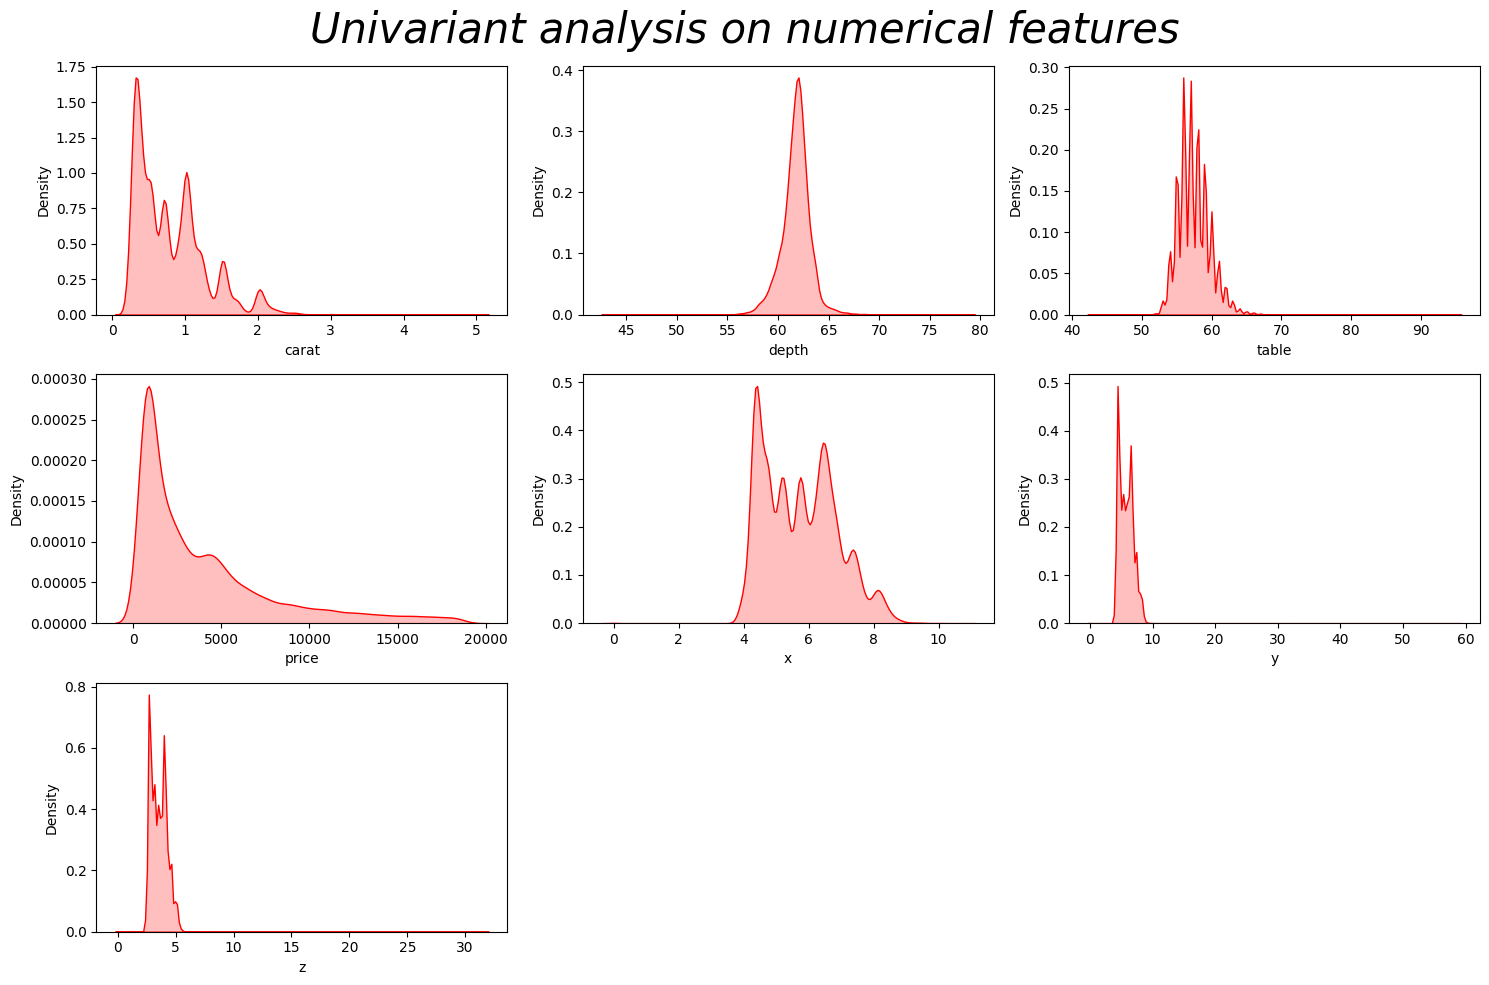

In [19]:
# Univariant analysis
# numerical features

plt.figure(figsize=(15,10))
plt.suptitle("Univariant analysis on numerical features", fontsize=30,  fontstyle='italic')
for i in range(len(num_cols)):
    plt.subplot(3,3,i+1)
    sns.kdeplot(x=df[num_cols[i]], shade=True, color = 'r')
    plt.tight_layout()

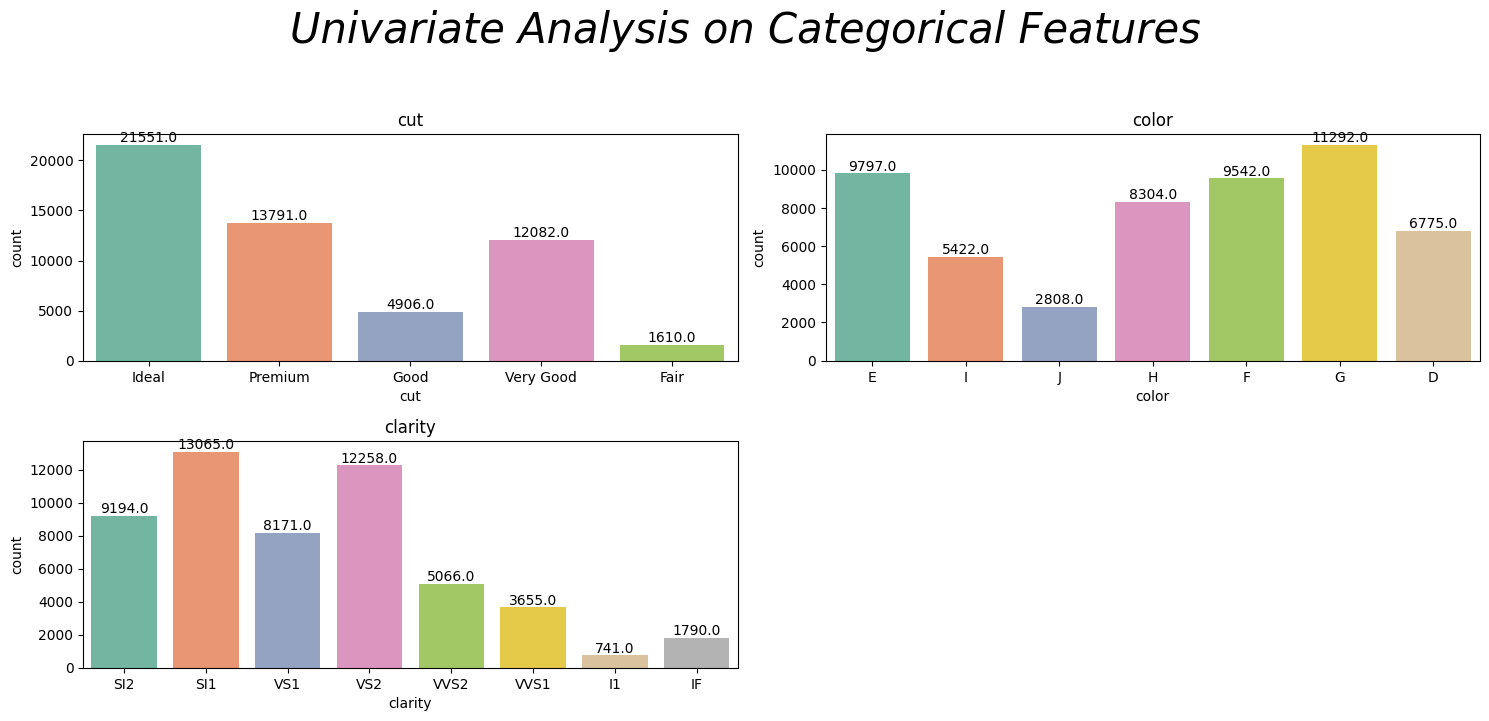

In [20]:
# Univariant analysis
# Categorical features
plt.figure(figsize=(15,10))
plt.suptitle("Univariate Analysis on Categorical Features",
             fontsize=30,
             fontstyle='italic')

for i in range(len(cat_cols)):
    plt.subplot(3,2, i + 1)

    ax = sns.countplot(x=df[cat_cols[i]], palette='Set2')

    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom')

    plt.title(cat_cols[i])


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

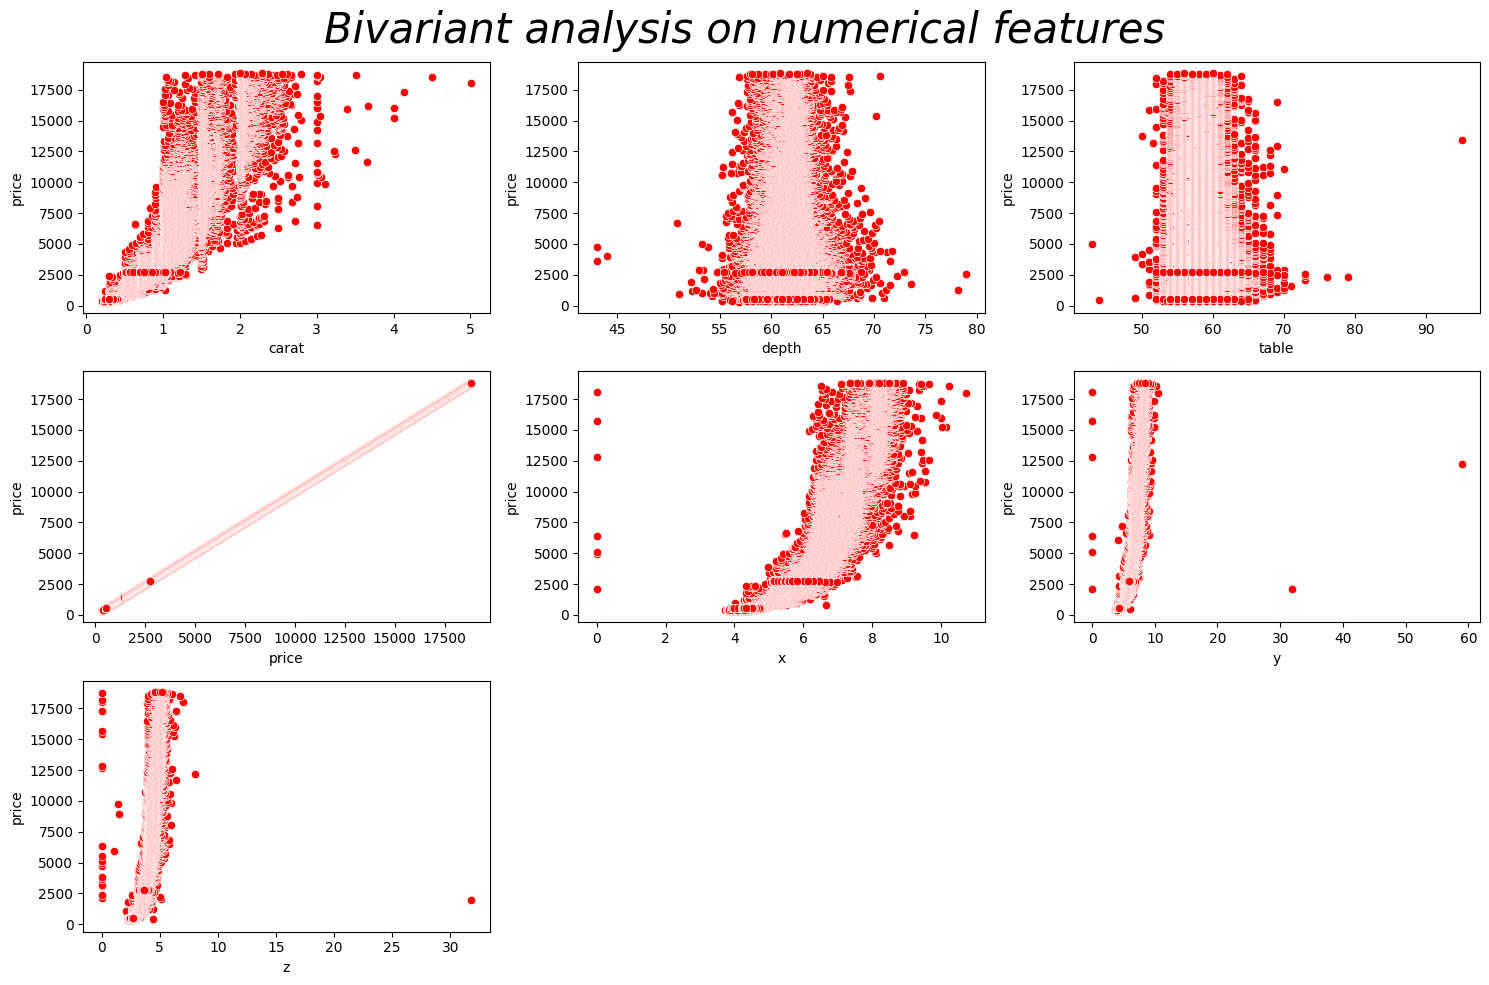

In [21]:
# bi variant

# numerical features

plt.figure(figsize=(15,10))
plt.suptitle("Bivariant analysis on numerical features", fontsize=30,  fontstyle='italic')
for i in range(len(num_cols)):
    plt.subplot(3,3,i+1)
    sns.scatterplot(x=df[num_cols[i]], y=df['price'],  color = 'r')
    plt.tight_layout()

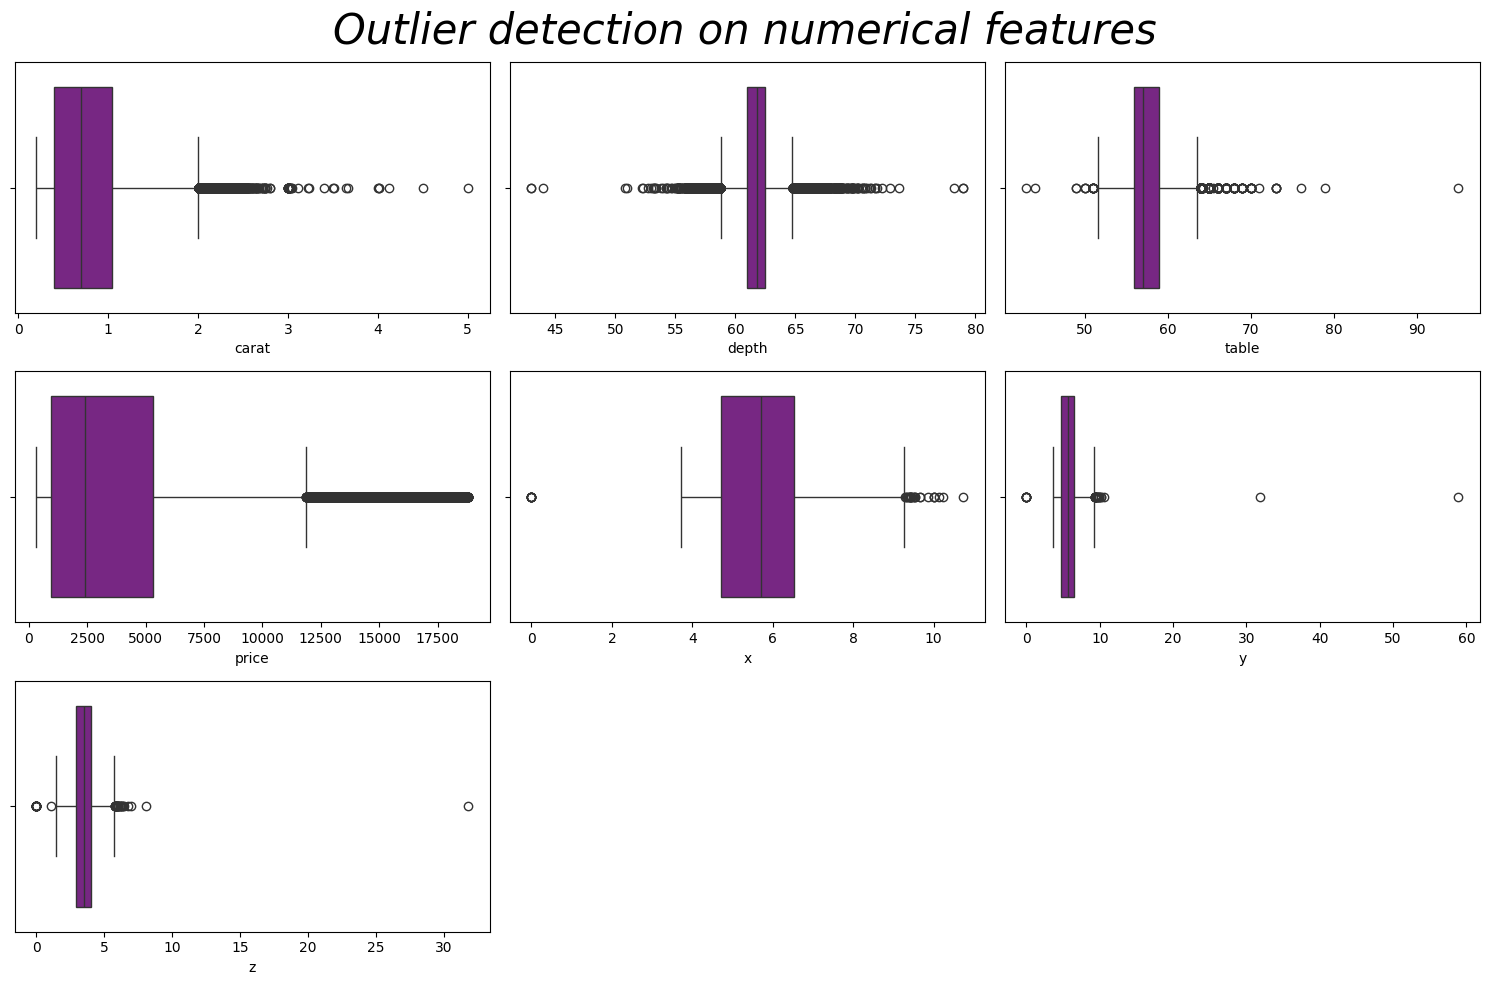

In [22]:
# outlier detection
# numerical features

plt.figure(figsize=(15,10))
plt.suptitle("Outlier detection on numerical features", fontsize=30,  fontstyle='italic')
for i in range(len(num_cols)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[num_cols[i]],color="#821892")
    plt.tight_layout()

<Axes: >

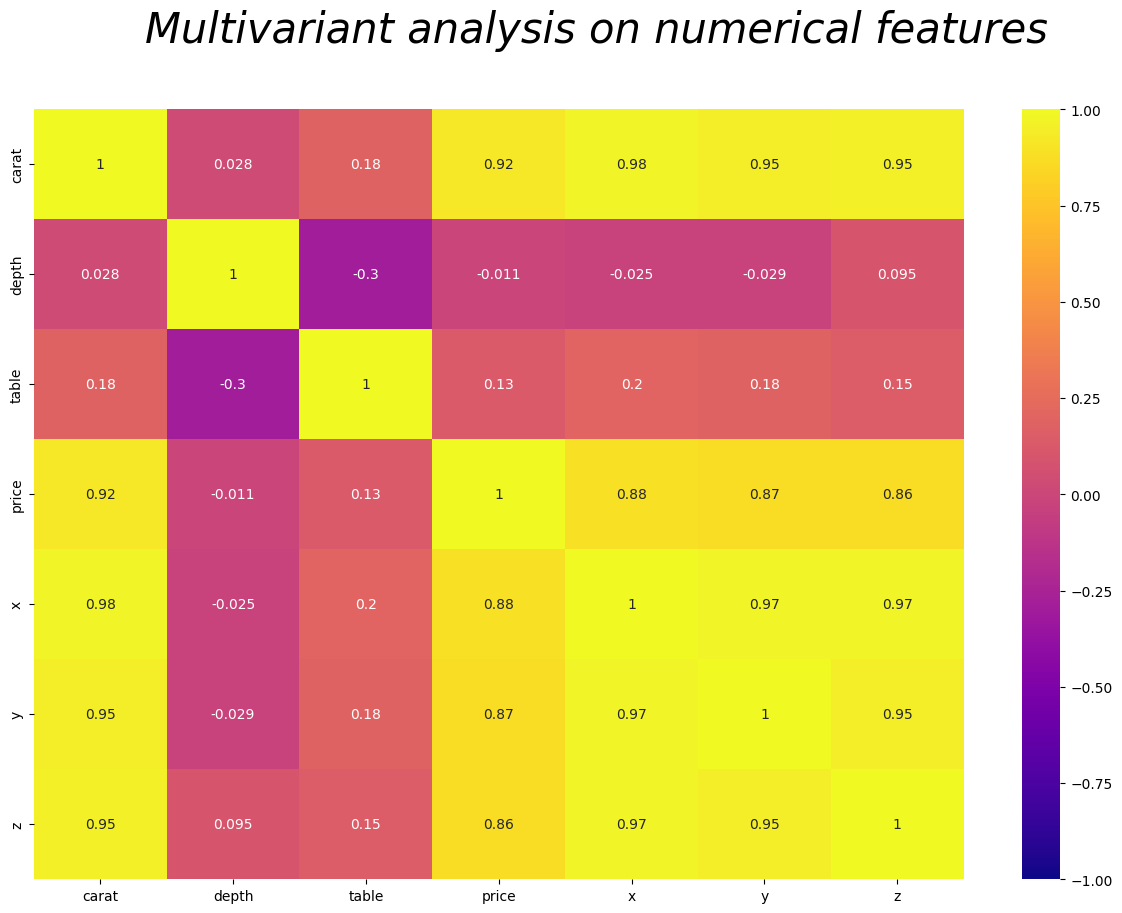

In [23]:
#Multivaraint
plt.figure(figsize=(15,10))
plt.suptitle("Multivariant analysis on numerical features", fontsize=30,  fontstyle='italic')
sns.heatmap(df[num_cols].corr(), cmap="plasma",annot=True, vmin=-1, vmax=+1)

# **data visualisation**

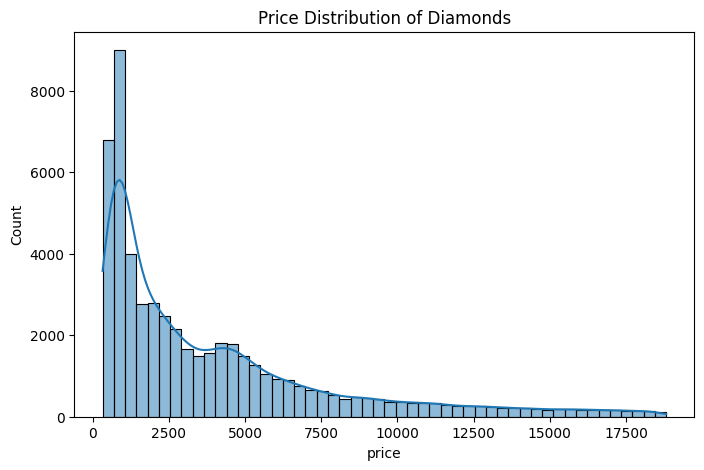

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution of Diamonds')
plt.show()

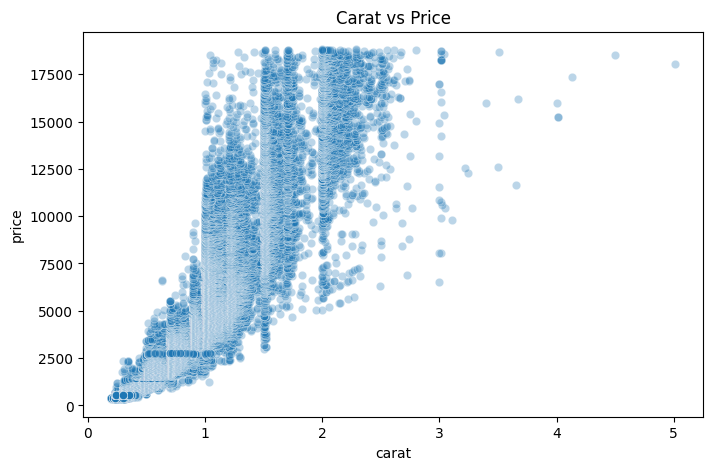

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='carat', y='price',
                data=df, alpha=0.3)
plt.title('Carat vs Price')
plt.show()

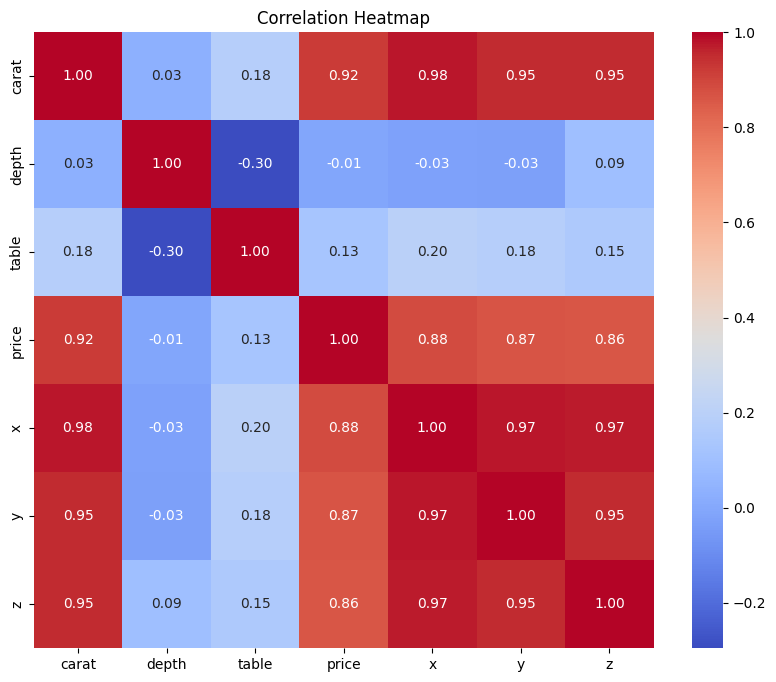

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

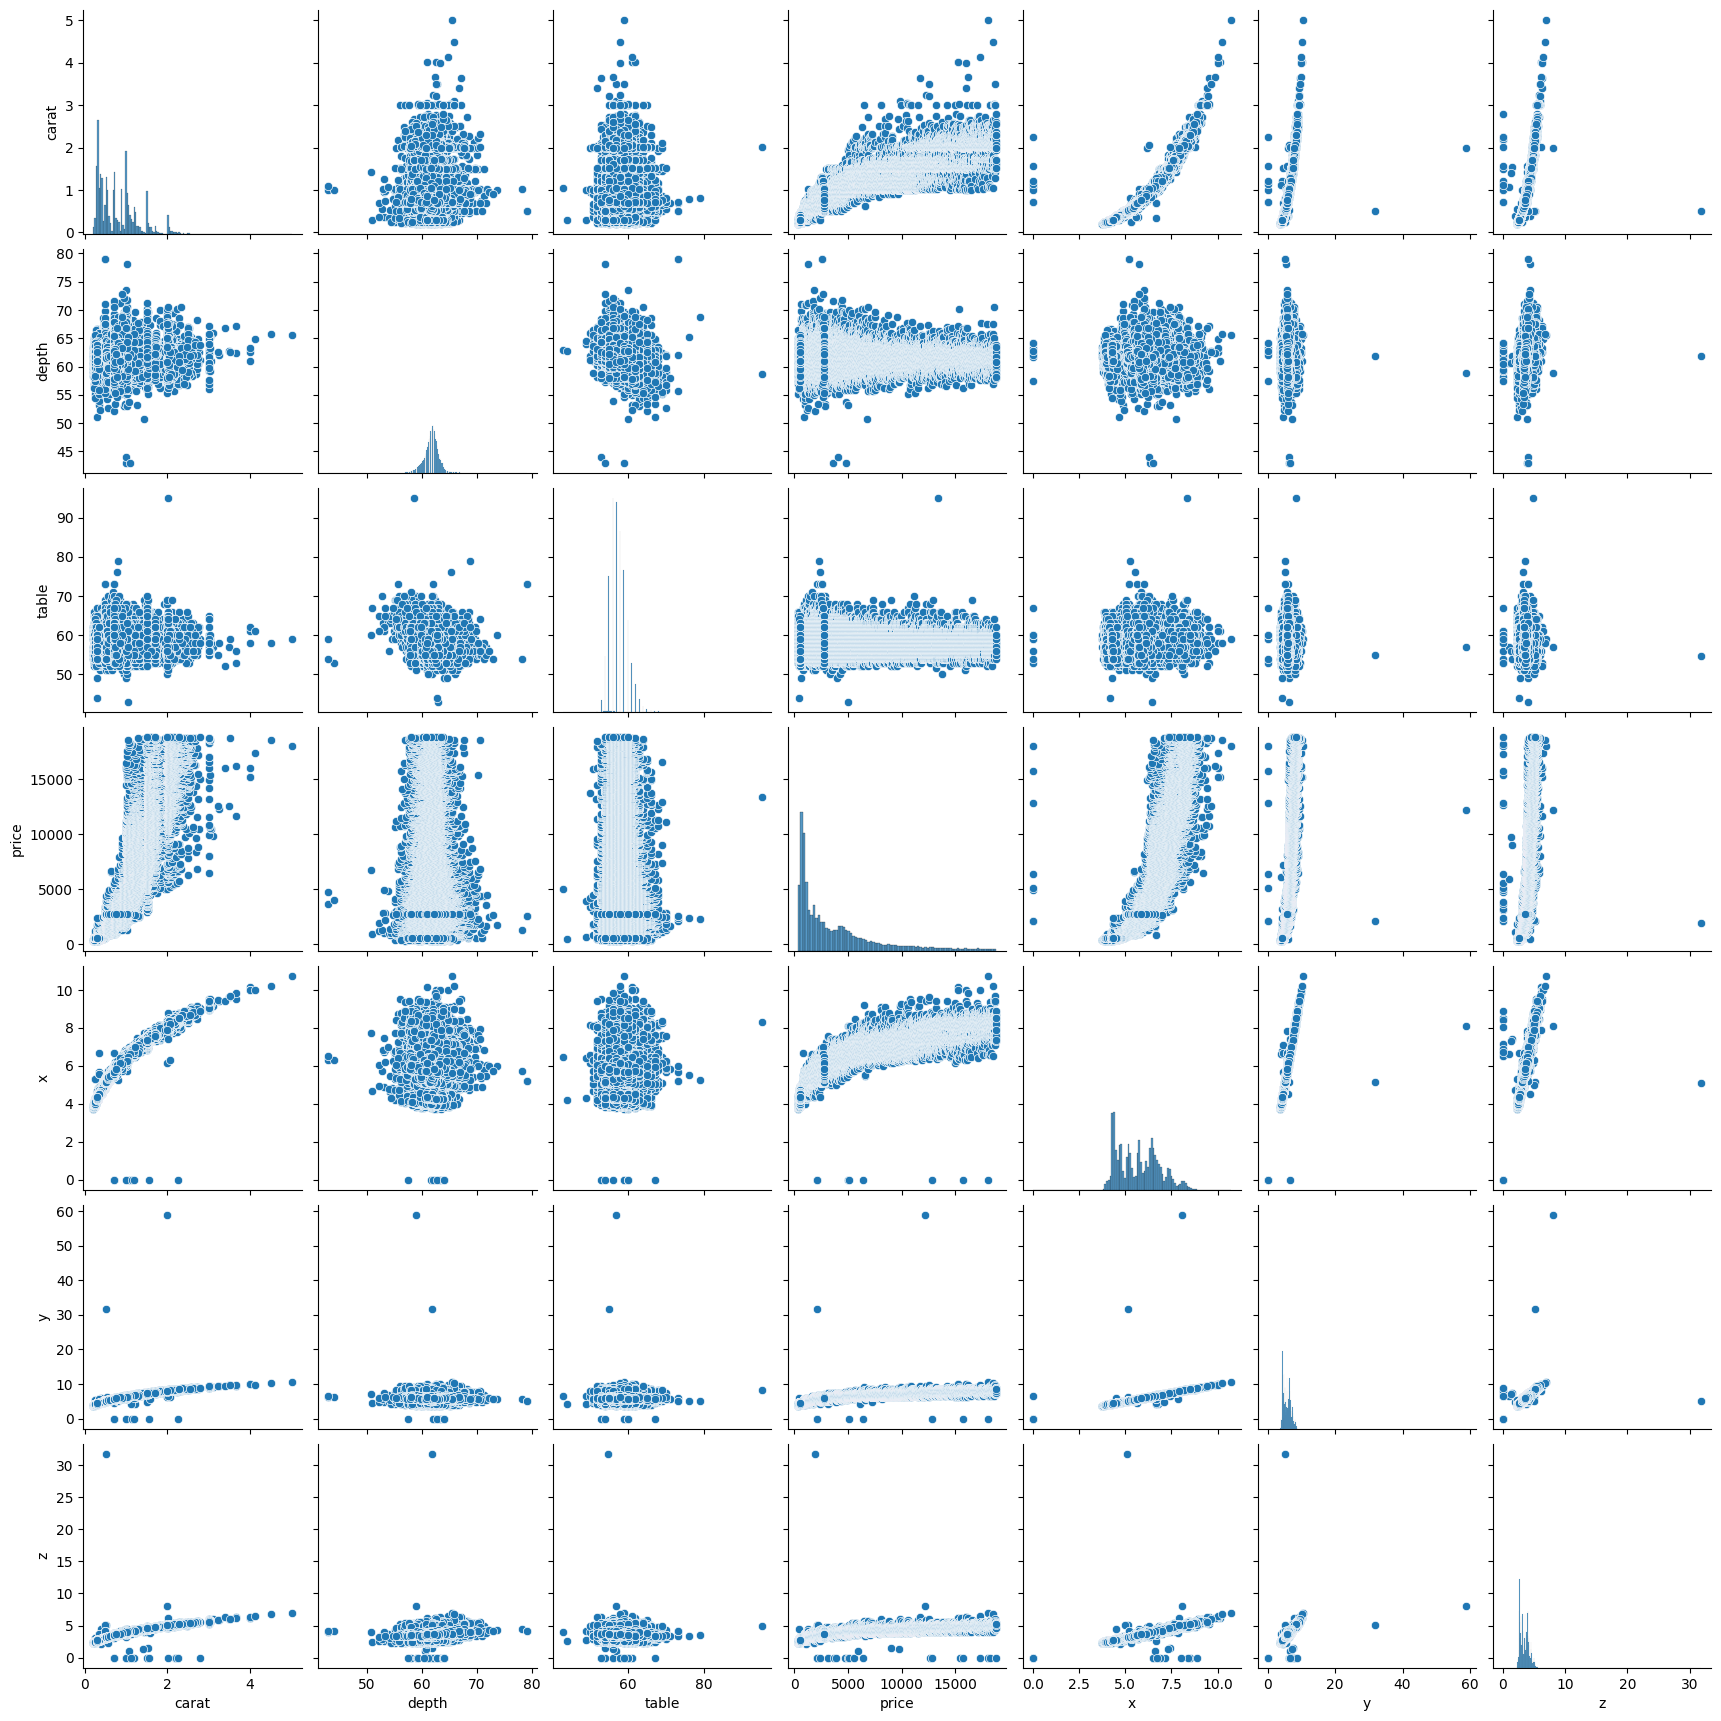

In [27]:
sns.pairplot(df[['carat','depth','table',
                 'price','x','y','z']])
plt.show()

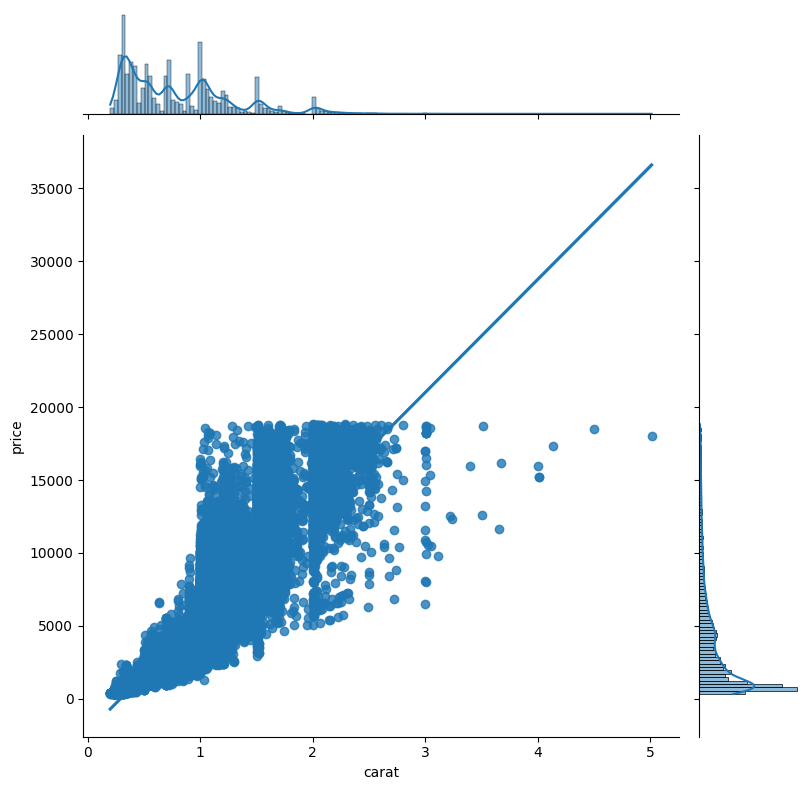

In [28]:
sns.jointplot(x='carat',
              y='price',
              data=df,
              kind='reg',
              height=8)
plt.show()

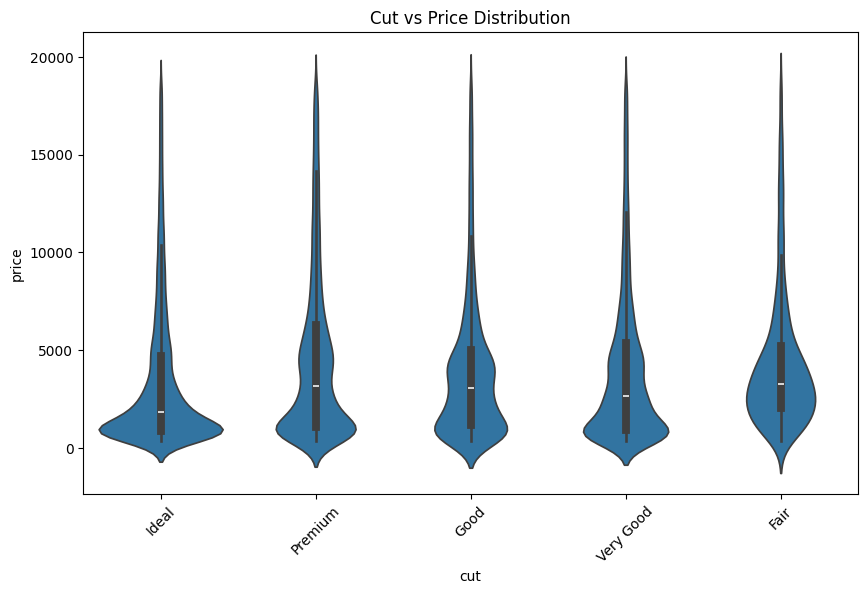

In [29]:
plt.figure(figsize=(10,6))
sns.violinplot(x='cut',
               y='price',
               data=df)

plt.title('Cut vs Price Distribution')
plt.xticks(rotation=45)
plt.show()

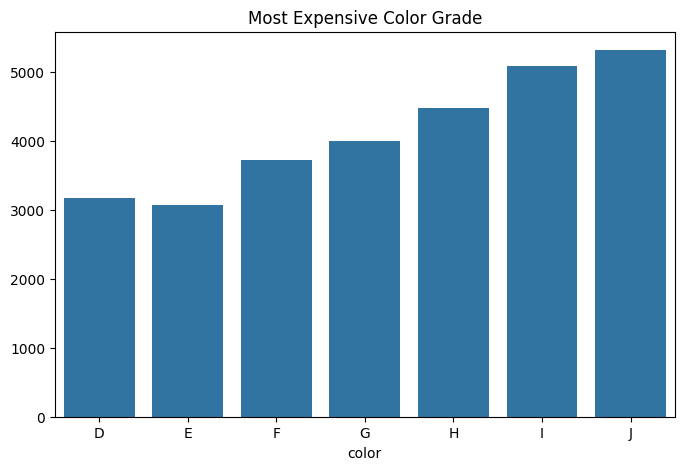

In [30]:
avg_price = df.groupby('color')['price'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=avg_price.index,
            y=avg_price.values)

plt.title('Most Expensive Color Grade')
plt.show()

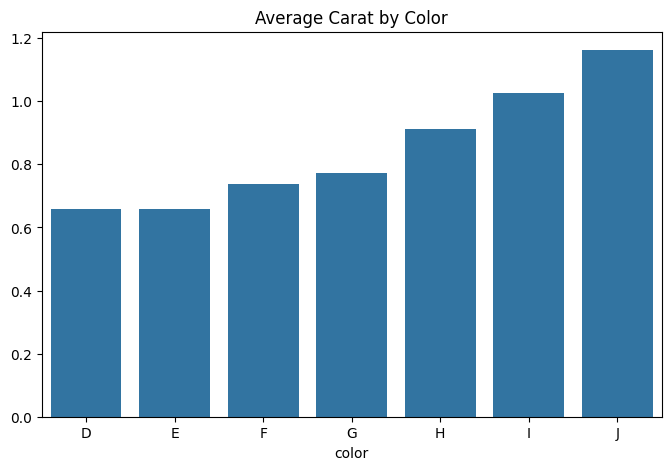

In [31]:
avg_carat = df.groupby('color')['carat'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=avg_carat.index,
            y=avg_carat.values)

plt.title('Average Carat by Color')
plt.show()

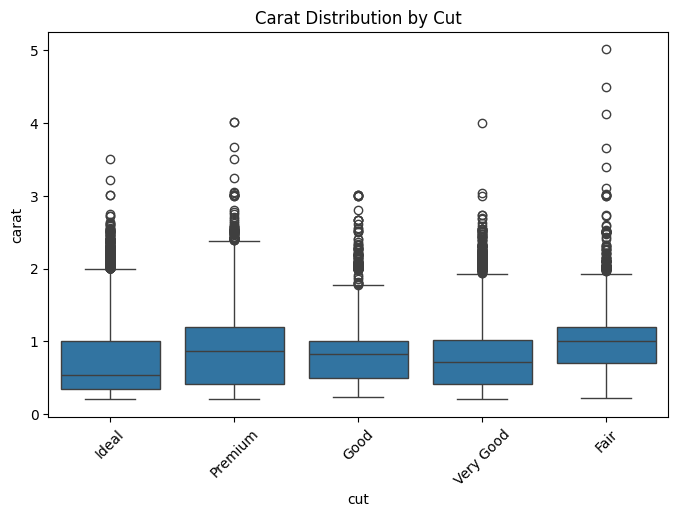

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x='cut',
            y='carat',
            data=df)

plt.title('Carat Distribution by Cut')
plt.xticks(rotation=45)
plt.show()

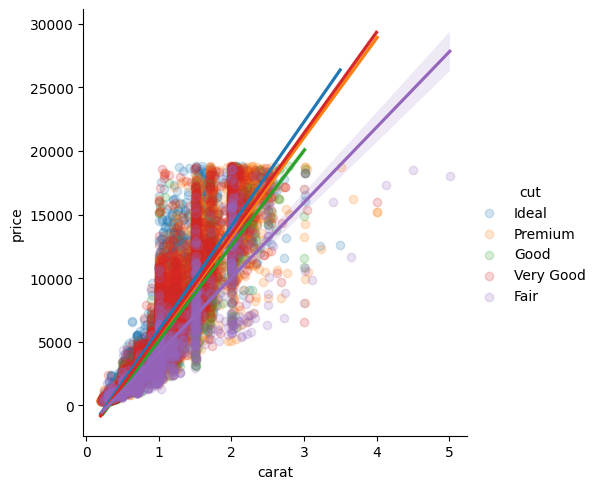

In [33]:
sns.lmplot(x='carat', y='price',
           hue='cut',
           data=df,
           scatter_kws={'alpha':0.2})

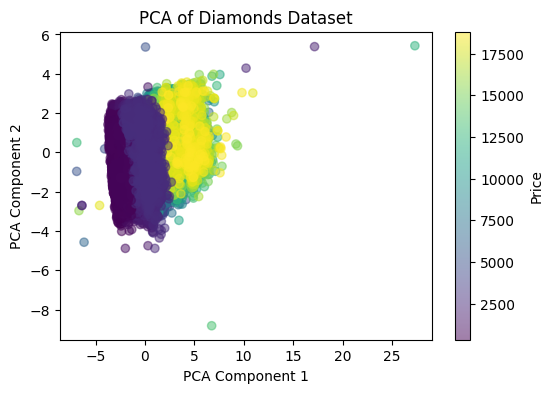

In [34]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_raw = df.drop(columns=['price'])

X = pd.get_dummies(X_raw, drop_first=True)

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=df['price'],
            cmap='viridis',
            alpha=0.5)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Diamonds Dataset')
plt.colorbar(label='Price')
plt.show()

<Axes: xlabel='price', ylabel='Count'>

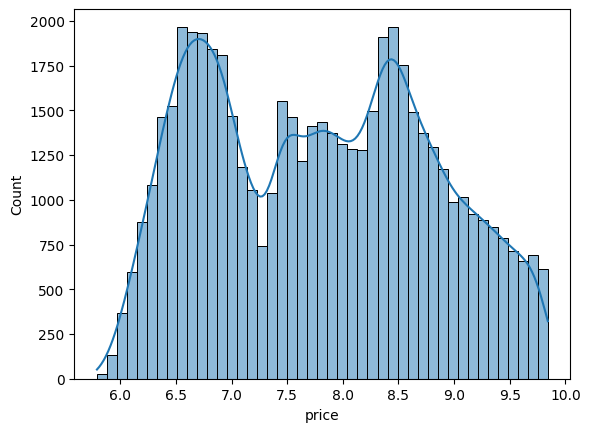

In [35]:
sns.histplot(np.log1p(df['price']), kde=True)

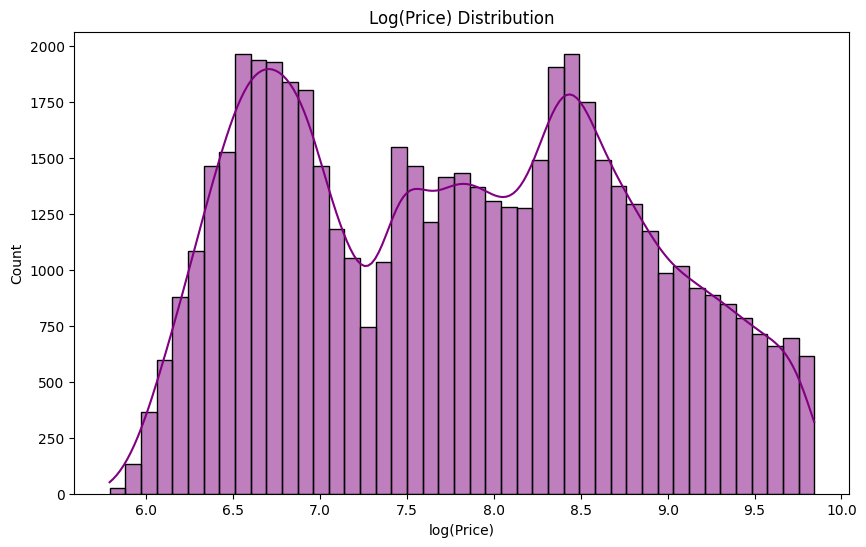

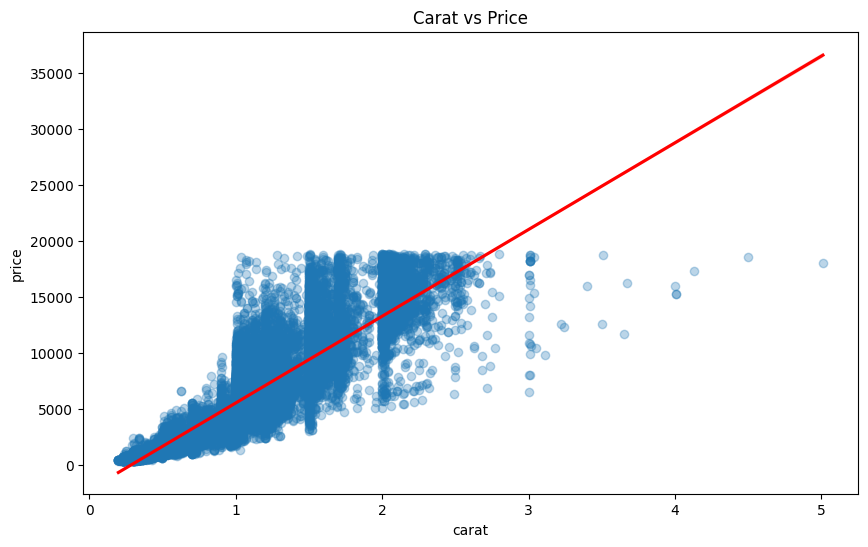

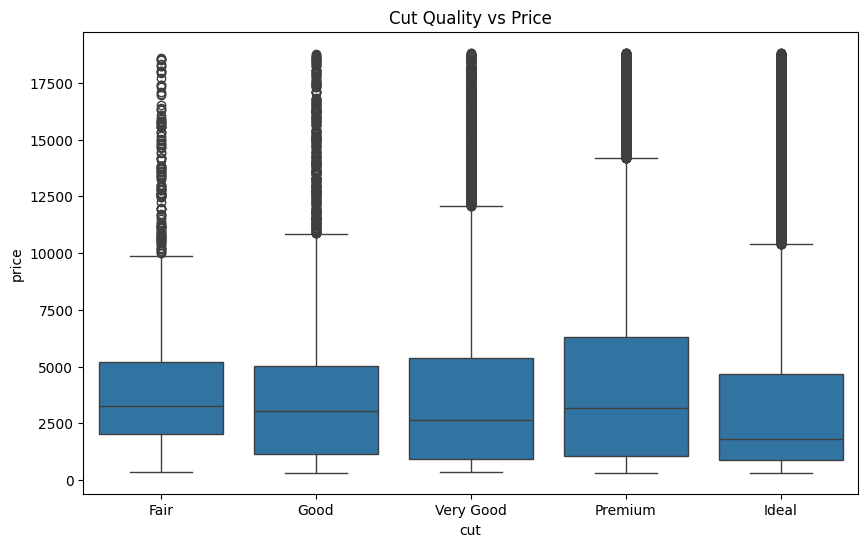

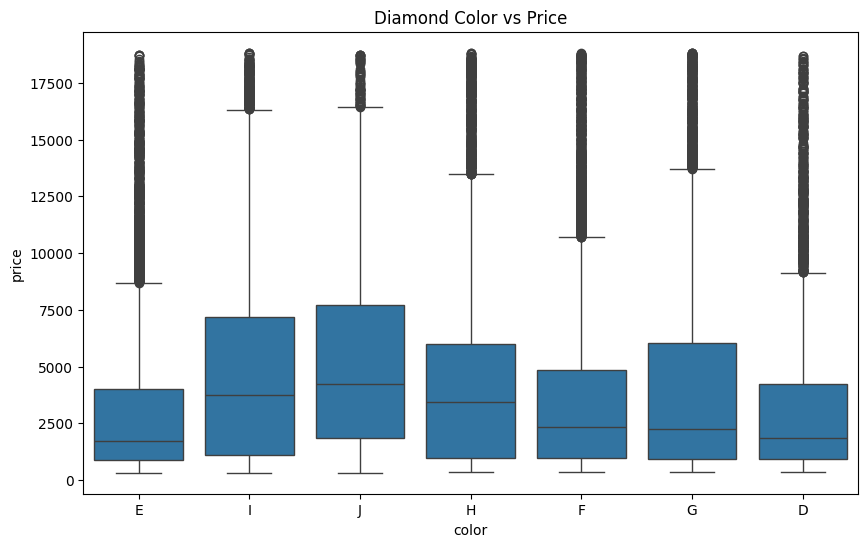

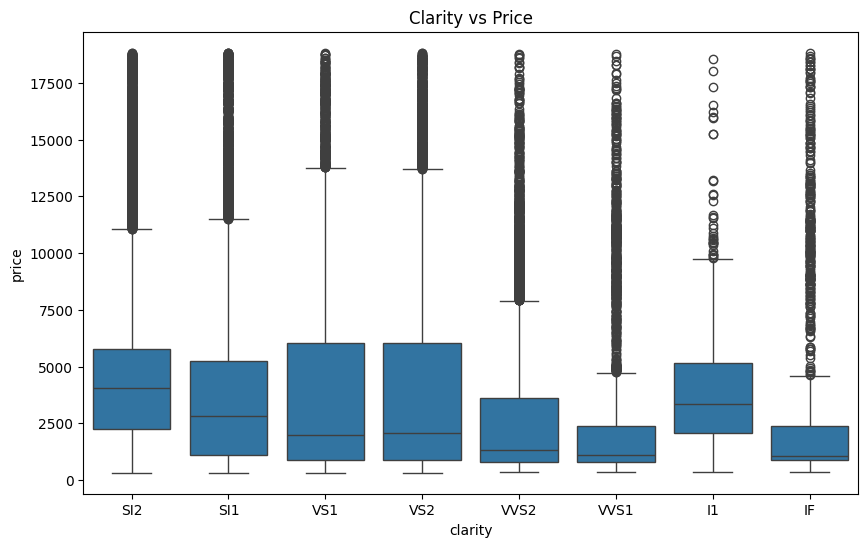

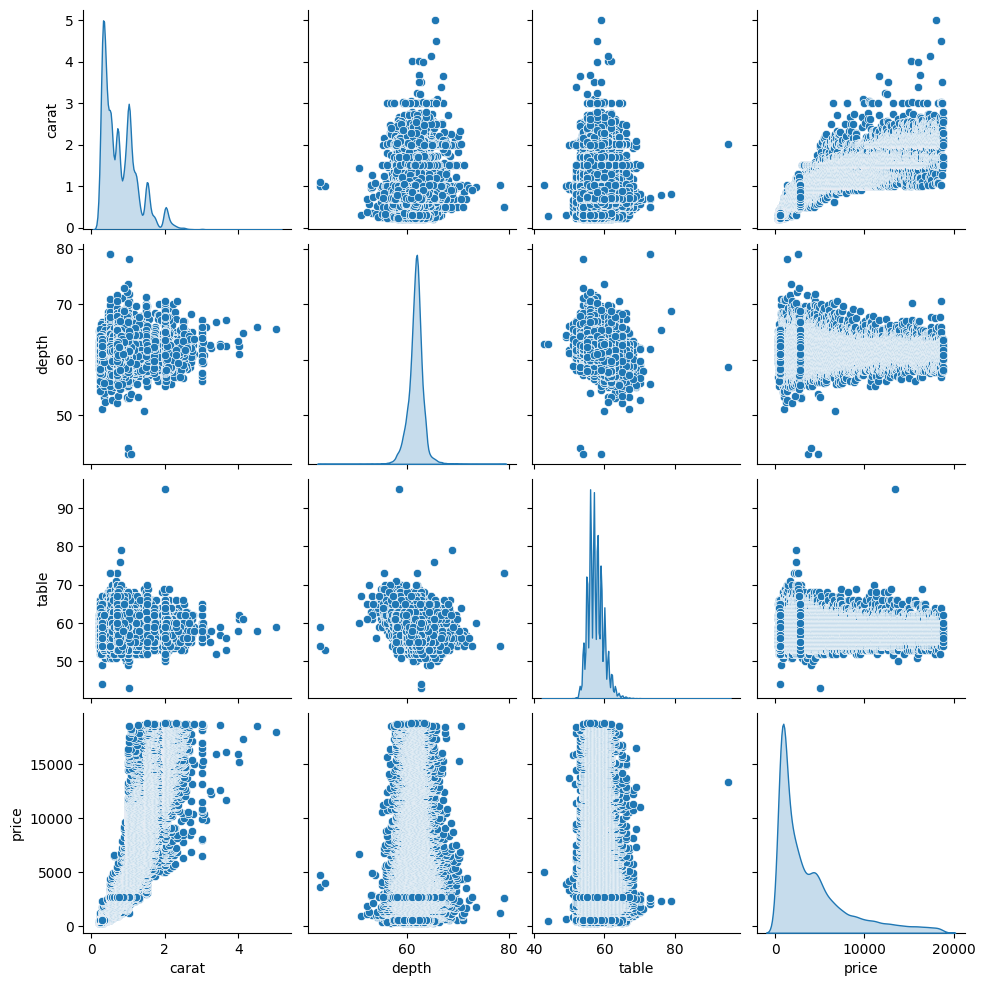

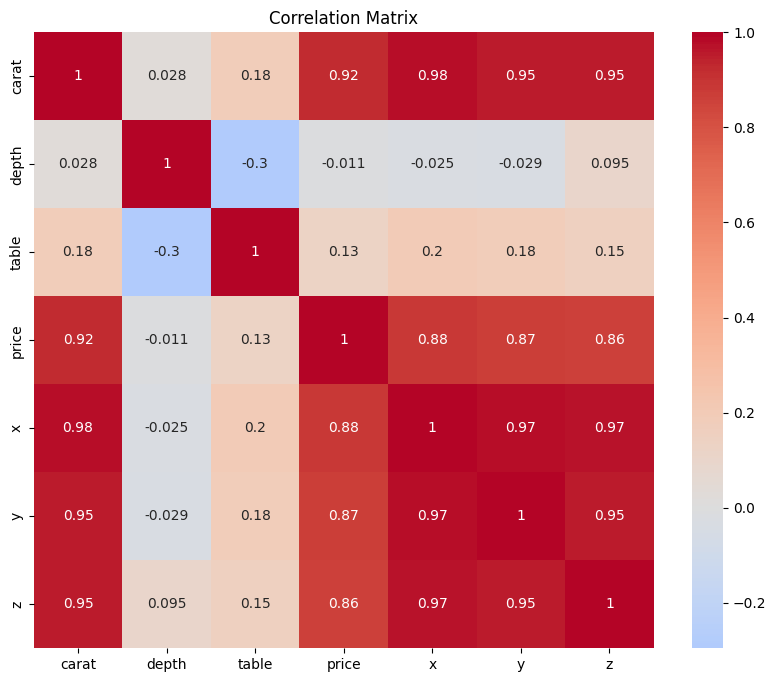

In [36]:


# 1. Price Distribution (Log scale - best for price)
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['price']), kde=True, color='purple')
plt.title('Log(Price) Distribution')
plt.xlabel('log(Price)')
plt.show()

# 2. Carat vs Price (Scatter + Regression)
plt.figure(figsize=(10,6))
sns.regplot(x='carat', y='price', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Carat vs Price')
plt.show()

# 3. Cut Quality vs Price
plt.figure(figsize=(10,6))
sns.boxplot(x='cut', y='price', data=df, order=['Fair','Good','Very Good','Premium','Ideal'])
plt.title('Cut Quality vs Price')
plt.show()

# 4. Color vs Price
plt.figure(figsize=(10,6))
sns.boxplot(x='color', y='price', data=df)
plt.title('Diamond Color vs Price')
plt.show()

# 5. Clarity vs Price
plt.figure(figsize=(10,6))
sns.boxplot(x='clarity', y='price', data=df)
plt.title('Clarity vs Price')
plt.show()

# 6. Pairplot (important variables)
sns.pairplot(df[['carat', 'depth', 'table', 'price']], diag_kind='kde')
plt.show()

# 7. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

final report

**feature engneering**

In [37]:

# ====================== 1. PHYSICAL / GEOMETRIC FEATURES ======================
df['volume'] = df['x'] * df['y'] * df['z']                    # Total volume
df['surface_area_approx'] = 2*(df['x']*df['y'] + df['x']*df['z'] + df['y']*df['z'])
df['density'] = df['carat'] / df['volume']                    # Carat per unit volume
df['aspect_ratio_xy'] = df['x'] / df['y']
df['aspect_ratio_xz'] = df['x'] / df['z']
df['table_to_depth_ratio'] = df['table'] / df['depth']

# ====================== 2. CARAT & SIZE TRANSFORMATIONS ======================
df['carat_log'] = np.log1p(df['carat'])
df['carat_sqrt'] = np.sqrt(df['carat'])
df['carat_squared'] = df['carat'] ** 2

# Binning carat (very useful for price prediction)
df['carat_bin'] = pd.cut(df['carat'], bins=[0, 0.5, 1, 1.5, 2, 5],
                        labels=['small', 'medium', 'large', 'xl', 'xxl'])

# ====================== 3. ORDINAL ENCODING (Diamonds specific) ======================
cut_order = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_order = {'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_order = {'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5, 'VVS2':6, 'VVS1':7, 'IF':8}

df['cut_ordinal'] = df['cut'].map(cut_order)
df['color_ordinal'] = df['color'].map(color_order)
df['clarity_ordinal'] = df['clarity'].map(clarity_order)

# Quality score (very powerful)
df['quality_score'] = (df['cut_ordinal'] + df['color_ordinal'] + df['clarity_ordinal']) / 3
df['quality_score_weighted'] = (df['cut_ordinal']*0.4 + df['color_ordinal']*0.3 + df['clarity_ordinal']*0.3)

# ====================== 4. INTERACTION FEATURES ======================
df['carat_x_quality'] = df['carat'] * df['quality_score']
df['carat_x_depth'] = df['carat'] * df['depth']
df['carat_x_table'] = df['carat'] * df['table']
df['volume_x_quality'] = df['volume'] * df['quality_score']

# Dimensional interactions
df['xy_ratio'] = df['x'] * df['y']
df['xyz_ratio'] = df['x'] * df['y'] * df['z'] / df['carat']   # efficiency

# ====================== 5. POLYNOMIAL & NON-LINEAR ======================
df['depth_table_interaction'] = df['depth'] * df['table']
df['depth_squared'] = df['depth'] ** 2
df['table_squared'] = df['table'] ** 2

# ====================== 6. AGGREGATE / GROUP FEATURES ======================
# Price per carat (target leakage warning - use only for EDA)
df['price_per_carat'] = df['price'] / df['carat']

# Group statistics (mean price by category)
for col in ['cut', 'color', 'clarity']:
    df[f'{col}_mean_price'] = df.groupby(col)['price'].transform('mean')
    df[f'{col}_price_ratio'] = df['price'] / df[f'{col}_mean_price']

# ====================== 7. RARE CATEGORY HANDLING ======================
# Combine rare clarity levels if needed
rare_clarity = ['I1']
df['clarity_grouped'] = df['clarity'].replace(rare_clarity, 'Rare')

print("Final Shape after FE:", df.shape)
print("\nNew Features Created:")
print([col for col in df.columns if col not in ['carat','cut','color','clarity','depth','table','price','x','y','z']])

Final Shape after FE: (53940, 42)

New Features Created:
['volume', 'surface_area_approx', 'density', 'aspect_ratio_xy', 'aspect_ratio_xz', 'table_to_depth_ratio', 'carat_log', 'carat_sqrt', 'carat_squared', 'carat_bin', 'cut_ordinal', 'color_ordinal', 'clarity_ordinal', 'quality_score', 'quality_score_weighted', 'carat_x_quality', 'carat_x_depth', 'carat_x_table', 'volume_x_quality', 'xy_ratio', 'xyz_ratio', 'depth_table_interaction', 'depth_squared', 'table_squared', 'price_per_carat', 'cut_mean_price', 'cut_price_ratio', 'color_mean_price', 'color_price_ratio', 'clarity_mean_price', 'clarity_price_ratio', 'clarity_grouped']


In [38]:
df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z,...,depth_squared,table_squared,price_per_carat,cut_mean_price,cut_price_ratio,color_mean_price,color_price_ratio,clarity_mean_price,clarity_price_ratio,clarity_grouped
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,...,3782.25,3025.0,1417.391304,3457.541970,0.094287,3076.752475,0.105956,5063.028606,0.064388,SI2
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,...,3576.04,3721.0,1552.380952,4584.257704,0.071113,3076.752475,0.105956,3996.001148,0.081582,SI1
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,...,3237.61,4225.0,1421.739130,3928.864452,0.083230,3076.752475,0.106281,3839.455391,0.085168,VS1
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,...,3893.76,3364.0,1151.724138,4584.257704,0.072858,5091.874954,0.065595,3924.989395,0.085096,VS2
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,...,4006.89,3364.0,1080.645161,3928.864452,0.085266,5323.818020,0.062925,5063.028606,0.066166,SI2


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   carat                    53940 non-null  float64 
 1   cut                      53940 non-null  object  
 2   color                    53940 non-null  object  
 3   clarity                  53940 non-null  object  
 4   depth                    53940 non-null  float64 
 5   table                    53940 non-null  float64 
 6   price                    53940 non-null  int64   
 7   x                        53940 non-null  float64 
 8   y                        53940 non-null  float64 
 9   z                        53940 non-null  float64 
 10  volume                   53940 non-null  float64 
 11  surface_area_approx      53940 non-null  float64 
 12  density                  53940 non-null  float64 
 13  aspect_ratio_xy          53933 non-null  float64 
 14  aspect

In [40]:
# inf ko NaN me convert karo
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# NaN count check
df.isna().sum().sort_values(ascending=False)

# NaN rows hata do
df.dropna(inplace=True)

In [41]:
drop_cols = [
    'Unnamed: 0',
    'carat_squared',
    'depth_squared',
    'table_squared',
    'carat_log',
    'carat_sqrt',
    'aspect_ratio_xy',
    'aspect_ratio_xz'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


In [42]:
target='price'

In [43]:
features = [
    'carat',
    'depth',
    'table',
    'x',
    'y',
    'z',
    'volume',
    'density',
    'quality_score',
    'quality_score_weighted',
    'carat_x_quality',
    'volume_x_quality',
    'cut_ordinal',
    'color_ordinal',
    'clarity_ordinal'
]

In [44]:
X = df[features]
y = df[target]

In [45]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

Numerical Columns: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'volume', 'surface_area_approx', 'density', 'table_to_depth_ratio', 'cut_ordinal', 'color_ordinal', 'clarity_ordinal', 'quality_score', 'quality_score_weighted', 'carat_x_quality', 'carat_x_depth', 'carat_x_table', 'volume_x_quality', 'xy_ratio', 'xyz_ratio', 'depth_table_interaction', 'price_per_carat', 'cut_mean_price', 'cut_price_ratio', 'color_mean_price', 'color_price_ratio', 'clarity_mean_price', 'clarity_price_ratio']
Categorical Columns: ['cut', 'color', 'clarity', 'clarity_grouped']


In [46]:
print(df.shape)

print(df.isnull().sum().sum())

print(df.duplicated().sum())

print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

(53919, 35)
0
145
0


In [47]:
# Drop duplicate rows and keep the first occurrence
df.drop_duplicates(inplace=True)

# Verify the new shape
print(df.shape)

(53774, 35)


In [48]:
print(df.shape)

print(df.isnull().sum().sum())

print(df.duplicated().sum())

print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

(53774, 35)
0
0
0


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [50]:
print(X_train.shape)
print(X_test.shape)

(43135, 15)
(10784, 15)


In [51]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [52]:
y_pred = rf.predict(X_test)

In [53]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R2 Score : 0.9822992277714445
MAE : 264.7977604540447
RMSE : 532.3654372880837


In [54]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                   Feature  Importance
10         carat_x_quality    0.778750
6                   volume    0.131831
0                    carat    0.030507
4                        y    0.016873
14         clarity_ordinal    0.015655
11        volume_x_quality    0.005229
13           color_ordinal    0.004112
12             cut_ordinal    0.003632
5                        z    0.003468
7                  density    0.002549
3                        x    0.002476
1                    depth    0.001837
9   quality_score_weighted    0.001446
2                    table    0.001385
8            quality_score    0.000251


In [55]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gbr.fit(X_train, y_train)

pred = gbr.predict(X_test)

print(r2_score(y_test, pred))

0.9830986356058427


In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [58]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
r2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1- r2) * (n-1) / (n - p - 1))
adjusted_r2

0.9822745703064159